### Task 1:

- We now have 8 features after encoding, which we perform first, as we need them to be encoded for accurate portrayal in the model.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

df = pd.read_csv("insurance.csv")
df = pd.get_dummies(df, columns=["sex", 'smoker', 'region'], drop_first=True)

X = df.drop(columns=['charges'])
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
print(len(X.columns))


8


### Task 2:

- With either a variance Threshold of .01 or .1, we do not drop any columns. With .2, we drop a majority of the binary columns, however this includes smoker, which we know to be an important feature. As such, we will not implement it as a form of feature control

In [2]:
selector = VarianceThreshold(threshold=.1)
selector.fit(X_train)

selected_features = X_train.columns[selector.get_support()].to_list()
X_train_vt = selector.transform(X_train)
X_test_vt = selector.transform(X_test)
print(selected_features)

['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


### Task 3:

- Smoker_yes has the highest score, which does match our intuition, as a high score expresses that the feature has a large impact on the target.

In [3]:
from sklearn.feature_selection import SelectKBest, f_regression

selector_kbest = SelectKBest(score_func=f_regression, k='all')
selector_kbest.fit(X_train, y_train)
kept = X_train.columns[selector.get_support()].tolist()
for name, score in zip(X.columns, selector_kbest.scores_):
    print(f"  {name}: {score:.2f}")


  age: 92.07
  bmi: 43.27
  children: 5.55
  sex_male: 3.46
  smoker_yes: 1659.95
  region_northwest: 1.22
  region_southeast: 4.89
  region_southwest: 1.31


### Task 4:

- All of our encoded columns, aside from smoker, has a coefficient of zero. This means that the coefficient was either at 0 already, or close enough to it, for lasso to drop it.
- In contrast, SelectKBest still considered the encoded columns to hold some significance.

In [4]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=100).fit(X_train, y_train)
coef = pd.Series(lasso.coef_, index=X.columns)
print("Lasso coef_ (sorted by size):")
print(coef.abs().sort_values(ascending=False).round(1).to_string())
print("\nZeroed out:", coef[coef == 0].index.tolist())

Lasso coef_ (sorted by size):
smoker_yes          23041.8
children              362.9
bmi                   324.8
age                   256.1
sex_male                0.0
region_northwest        0.0
region_southeast        0.0
region_southwest        0.0

Zeroed out: ['sex_male', 'region_northwest', 'region_southeast', 'region_southwest']


### Task 5:

- RF: Smoker, BMI, Age
- Lasso: Smoker, Children, BMI
- KBest: Smoker, Age, BMI
- They all agree that smoker is the most important, and while generally considering BMI/AGE to be some of the most important factors, disagree on the order. Lasso additionally weighs Children heavier.


Random Forest feature_importances_:
smoker_yes          0.6107
bmi                 0.2118
age                 0.1340
children            0.0207
sex_male            0.0068
region_northwest    0.0058
region_southeast    0.0057
region_southwest    0.0045


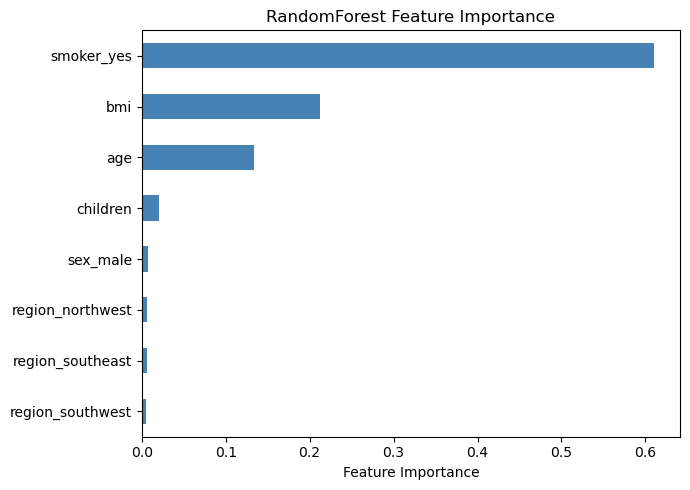

In [5]:
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt
rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nRandom Forest feature_importances_:")
print(imp.round(4).to_string())

scores_sorted = imp.sort_values(ascending=False)
# Create a horizontal bar chart of feature scores
fig, ax = plt.subplots(figsize=(7, 5))

scores_sorted.plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel("Feature Importance")
ax.set_title("RandomForest Feature Importance")
ax.invert_yaxis()  # Highest score at the top

plt.tight_layout()
plt.show()

### Task 6:

- None of the features moved up or down significantly. You must evaluate it on test data, as overfit training data has a disproportionate impact on permutation importance scoring.

In [6]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=0)
perm = pd.Series(pi.importances_mean,
                 index=X.columns).sort_values(ascending=False)
print("\nPermutation importance (test set):")
print(perm.round(4).to_string())


Permutation importance (test set):
smoker_yes          1.3565
bmi                 0.2680
age                 0.1866
children            0.0277
region_southwest    0.0052
region_southeast    0.0036
region_northwest   -0.0018
sex_male           -0.0034


### Task 7

In [7]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('rfr', RandomForestRegressor(random_state=0))
])

params = {
    'rfr__n_estimators': [50, 100, 200],
    'rfr__max_depth': [None, 5, 10]
}

gs = GridSearchCV(pipe, params, scoring='r2', cv=5, n_jobs=-1)
gs.fit(X_train, y_train)


print(f'Best Parameters: ')
for k,v in gs.best_params_.items():
    print(f'    {k}: {v}')

print("Best CV R2 :", round(gs.best_score_, 3))   # avg across 5 folds
print("Test R2    :", round(gs.score(X_test, y_test), 3))  # final hold-out

Best Parameters: 
    rfr__max_depth: 5
    rfr__n_estimators: 100
Best CV R2 : 0.845
Test R2    : 0.873


data leakage. The GridSearchCV with scaling *inside* the pipeline allows each cross-validation to scale on its specific training folds, then test it on the test fold that it did not scale on, avoiding data leakage. If we scaled outside of the pipeline, each time a fold is tested, it has been included in the scaling and therefore leaked into the training set.

# Advanced Tasks

### Advanced Task 1

In [8]:
pipe2 = Pipeline(steps=[
    ('skb', SelectKBest(f_regression)),
    ('scale', StandardScaler()),
    ('rfr', RandomForestRegressor(random_state=0))
])

params2 = {
    'rfr__n_estimators': [50, 100, 200],
    'rfr__max_depth': [None, 5, 10],
    'skb__k': [3, 5, 7]
}

gs2 = GridSearchCV(pipe2, params2, scoring='r2', cv=5, n_jobs=-1)
gs2.fit(X_train, y_train)
print(f'Training complete. :)')

Training complete. :)


In [9]:
print(f'Best k: {gs2.best_params_['skb__k']}')
print(f'Best features: {X.columns[gs2.best_estimator_.named_steps['skb'].get_support()]}')

print(f'\nBest Score: {gs2.best_score_.round(3)}')
print("Test R2    :", round(gs2.score(X_test, y_test), 3))

Best k: 7
Best features: Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_southeast',
       'region_southwest'],
      dtype='object')

Best Score: 0.845
Test R2    : 0.871


### Advanced Task 2

In [10]:
params_large = {
    'rfr__n_estimators': [50, 100, 200, 300, 500],
    'rfr__max_depth': [None, 3, 5, 10, 20],
    'skb__k': [3, 4, 5, 6, 7]
}

gs_rando = RandomizedSearchCV(pipe2, params_large, scoring='r2', cv=5, n_jobs=-1, n_iter=20)
gs_rando.fit(X_train, y_train)
print(f'Training complete. :)')

Training complete. :)


In [11]:
for k,v in gs_rando.best_params_.items():
    print(f'    {k}: {v}')

print(f'Best features: {X.columns[gs_rando.best_estimator_.named_steps['skb'].get_support()]}')

print(f'\nBest Score: {gs_rando.best_score_.round(3)}')
print("Test R2    :", round(gs_rando.score(X_test, y_test), 3))

    skb__k: 5
    rfr__n_estimators: 300
    rfr__max_depth: 3
Best features: Index(['age', 'bmi', 'children', 'smoker_yes', 'region_southeast'], dtype='object')

Best Score: 0.846
Test R2    : 0.867


We would prefer `RandomizedSearchCV` when we are testing a large number of parameters and don't want the program to run as long.

# Extra Credit

In [39]:
coef = coef.abs().sort_values(ascending=False).round(1).to_dict()
scores_sorted = scores_sorted.to_dict()

AttributeError: 'dict' object has no attribute 'abs'

In [38]:
selectkbestfeatures = {}
for name, score in zip(X.columns, selector_kbest.scores_):
    selectkbestfeatures[name] = score
selectkbestfeatures = dict(sorted(selectkbestfeatures.items(), key=lambda item: item[1], reverse=True))
features = [selectkbestfeatures, coef, scores_sorted]

def selection_report(feat_imp):
    feature_rankings = {}
    for feature_list in feat_imp:
        for index, feature in enumerate(feature_list):
            if feature in feature_rankings:
                feature_rankings[feature] += index +1
            else:
                feature_rankings[feature] = index +1
        index += 1
    return feature_rankings

results = selection_report(features)

results_sorted = dict(sorted(results.items(), key=lambda item: item[1]))

print(results_sorted)




{'smoker_yes': 3, 'bmi': 8, 'age': 9, 'children': 10, 'sex_male': 16, 'region_southeast': 19, 'region_northwest': 20, 'region_southwest': 23}
